# 11.2-11.3 MCMC とギブスサンプリング (MCMC & Gibbs Sampling)

本ノートブックでは、高次元の複雑な確率分布から効率的にサンプリングするための中心的手法である **マルコフ連鎖モンテカルロ (MCMC)** を学びます。
詳細釣り合い条件と定常分布、二変量相関ガウス分布に対する **メトロポリス法の受容・棄却軌跡（PRML Figure 11.9）**、非対称提案分布を扱う **メトロポリス・ヘイスティングス法 (MH)**、および条件付き完全事後分布からの座標軸交互更新による **ギブスサンプリングの階段状探索軌跡（PRML Figure 11.11）** を完全再現します。

## 11.2 メトロポリス法による二変量ガウスのサンプリング (PRML Figure 11.9)

### メトロポリスアルゴリズム
対称な提案分布 $q(\mathbf{z}^* | \mathbf{z}^{(\tau)}) = q(\mathbf{z}^{(\tau)} | \mathbf{z}^*)$（例：等方ガウス分布 $\mathcal{N}(\mathbf{z}^* | \mathbf{z}^{(\tau)}, \epsilon^2 \mathbf{I})$）を用います。
受容確率は：
$$ A(\mathbf{z}^*, \mathbf{z}^{(\tau)}) = \min\left(1, \frac{\tilde{p}(\mathbf{z}^*)}{\tilde{p}(\mathbf{z}^{(\tau)})}\right) $$
- $\tilde{p}(\mathbf{z}^*) \ge \tilde{p}(\mathbf{z}^{(\tau)})$ （確率密度が高い領域への移動）なら必ず受容（$A = 1$）。
- $\tilde{p}(\mathbf{z}^*) < \tilde{p}(\mathbf{z}^{(\tau)})$ （確率密度が低い領域への移動）なら確率 $A$ で受容し、棄却された場合は現在位置に留まります（$\mathbf{z}^{(\tau+1)} = \mathbf{z}^{(\tau)}$）。

PRML Figure 11.9 では、相関を持つ2次元ガウス分布に対し、提案ステップと受容（赤矢印）・棄却（青矢印）の軌跡が示されています。

Plot saved to: result/fig11_9_metropolis_gaussian_steps.png


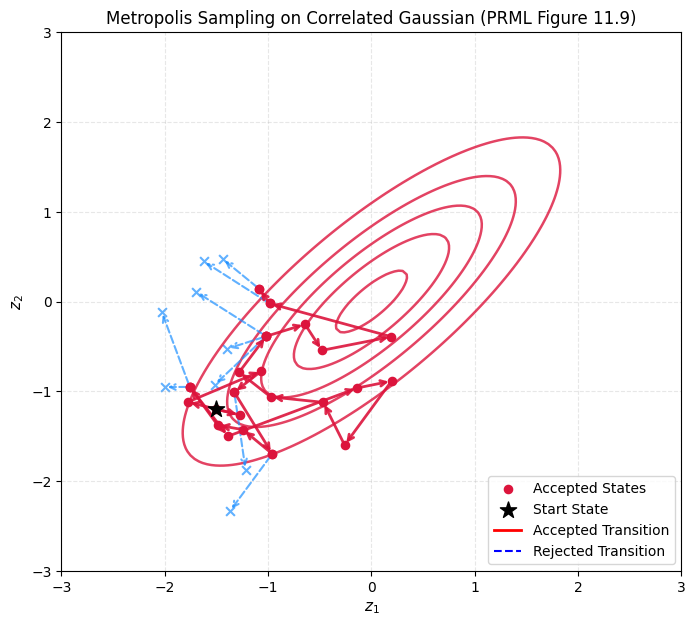

In [1]:
import sys, os
sys.path.append(os.path.abspath('../'))
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal
from common.plot_utils import save_plot, setup_style
setup_style()

# 目標分布: 相関を持つ二次元ガウス分布
mean_target = np.array([0.0, 0.0])
cov_target = np.array([[1.0, 0.8], [0.8, 1.0]])
target_dist = multivariate_normal(mean=mean_target, cov=cov_target)

def log_target(z):
    return target_dist.logpdf(z)

# 等方ガウス提案分布によるメトロポリスサンプリング
np.random.seed(42)
step_size = 0.45
n_steps = 30
current = np.array([-1.5, -1.2])

accepted_moves = []
rejected_moves = []
path = [current.copy()]

for step in range(n_steps):
    candidate = current + np.random.normal(0, step_size, size=2)
    log_alpha = log_target(candidate) - log_target(current)
    
    if np.log(np.random.uniform(0, 1)) < log_alpha:
        accepted_moves.append((current.copy(), candidate.copy()))
        current = candidate
    else:
        rejected_moves.append((current.copy(), candidate.copy()))
    path.append(current.copy())

# グリッド等高線
x_grid = np.linspace(-3.0, 3.0, 150)
y_grid = np.linspace(-3.0, 3.0, 150)
X, Y = np.meshgrid(x_grid, y_grid)
pos = np.dstack((X, Y))
Z = target_dist.pdf(pos)

# PRML Figure 11.9 のプロット
fig, ax = plt.subplots(figsize=(8, 7))

ax.contour(X, Y, Z, levels=5, colors='crimson', linewidths=1.8, alpha=0.8)

# 棄却されたステップ (青の破線矢印)
for src, dst in rejected_moves:
    ax.annotate('', xy=dst, xytext=src,
                arrowprops=dict(arrowstyle='->', color='dodgerblue', linestyle='--', lw=1.5, alpha=0.7))
    ax.scatter(dst[0], dst[1], color='dodgerblue', marker='x', s=40, alpha=0.7)

# 受容されたステップ (赤の実線矢印)
for src, dst in accepted_moves:
    ax.annotate('', xy=dst, xytext=src,
                arrowprops=dict(arrowstyle='->', color='crimson', lw=2.0, alpha=0.9))

# 軌跡の点
path = np.array(path)
ax.scatter(path[:, 0], path[:, 1], color='crimson', s=35, zorder=5, label='Accepted States')
ax.scatter(path[0, 0], path[0, 1], color='black', marker='*', s=150, zorder=6, label='Start State')

ax.plot([], [], 'r-', lw=2, label='Accepted Transition')
ax.plot([], [], 'b--', lw=1.5, label='Rejected Transition')

ax.set_title('Metropolis Sampling on Correlated Gaussian (PRML Figure 11.9)', fontsize=12)
ax.set_xlabel('$z_1$', fontsize=11); ax.set_ylabel('$z_2$', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig11_9_metropolis_gaussian_steps.png')
plt.show()

## 11.3 ギブスサンプリング (PRML Figure 11.11)

ギブスサンプリングは、他の全変数を条件付けた完全条件付き事後分布 $p(z_i | \mathbf{z}_{\backslash i})$ から1変数ずつ順次サンプリングします。
各サブステップでの受容確率は常に $1.0$（棄却ゼロ）です。

2変量ガウス分布 $p(z_1, z_2)$ において：
- $p(z_1 | z_2) = \mathcal{N}\left(\mu_1 + \frac{\Sigma_{12}}{\Sigma_{22}}(z_2 - \mu_2), \Sigma_{11} - \frac{\Sigma_{12}^2}{\Sigma_{22}}\right)$
- $p(z_2 | z_1) = \mathcal{N}\left(\mu_2 + \frac{\Sigma_{21}}{\Sigma_{11}}(z_1 - \mu_1), \Sigma_{22} - \frac{\Sigma_{21}^2}{\Sigma_{11}}\right)$
各ステップが必ず座標軸に平行（水平 $\to$ 垂直 $\to$ 水平 $\dots$）に直角に進むため、**階段状（ジグザグ）の軌跡（PRML Figure 11.11）** が形成されます。

Plot saved to: result/fig11_11_gibbs_sampling_steps.png


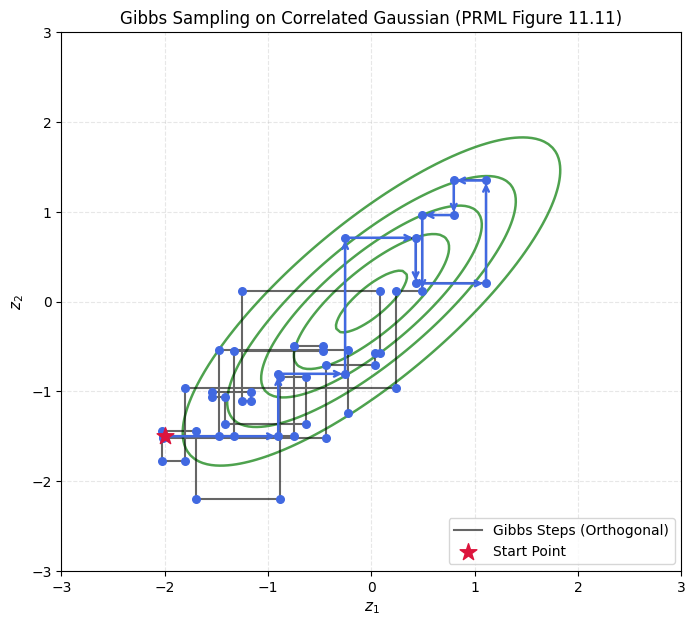

In [2]:
from common.sampling_utils import gibbs_sampler_2d

# 条件付き分布のパラメータ計算
# rho = 0.8, mu = 0, var = 1
rho = 0.8
cond_var = 1.0 - rho**2
cond_std = np.sqrt(cond_var)

cond_x = lambda y: np.random.normal(rho * y, cond_std)
cond_y = lambda x: np.random.normal(rho * x, cond_std)

# ギブスサンプリングの実行
initial_pt = [-2.0, -1.5]
gibbs_path = gibbs_sampler_2d(cond_x, cond_y, initial_pt, n_samples=25, random_state=42)

# PRML Figure 11.11 プロット
fig, ax = plt.subplots(figsize=(8, 7))

ax.contour(X, Y, Z, levels=5, colors='forestgreen', linewidths=1.8, alpha=0.8)

# 階段状のサンプリング軌跡の描画
ax.plot(gibbs_path[:, 0], gibbs_path[:, 1], 'k-', lw=1.5, alpha=0.6, label='Gibbs Steps (Orthogonal)')
ax.scatter(gibbs_path[:, 0], gibbs_path[:, 1], color='royalblue', s=30, zorder=5)

# 最初の数ステップに矢印を付与
for i in range(min(12, len(gibbs_path) - 1)):
    ax.annotate('', xy=gibbs_path[i+1], xytext=gibbs_path[i],
                arrowprops=dict(arrowstyle='->', color='royalblue', lw=1.8))

ax.scatter(initial_pt[0], initial_pt[1], color='crimson', marker='*', s=160, zorder=6, label='Start Point')

ax.set_title('Gibbs Sampling on Correlated Gaussian (PRML Figure 11.11)', fontsize=12)
ax.set_xlabel('$z_1$', fontsize=11); ax.set_ylabel('$z_2$', fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, linestyle='--', alpha=0.3)

save_plot(fig, 'result', 'fig11_11_gibbs_sampling_steps.png')
plt.show()